# Engenharia de Aprendizado de Máquina
## Trabalho Prático - Ambientação

Aluno: João Gabriel Angelo Bradachi - 5078
Professor: Fabricio Silva

## Sumário
* [1. Introdução](#introdução)
* [2. Obtendo os dados](#obtendo-dados)
* [2. Análise exploratória](#explorando-dados)
* [3. Conclusão](#conclusao)

## <a id="introducao"></a>Introdução

O objetivo desse trabalho é se ambientar com programação em nuvem e participar de uma competição no Kaggle 

O servidor da AWS usado para esse trabalho é uma instância t3.small. Nos próximos trabalhos irei pegar uma instância mais potente para fazer o processamento das atividades. A imagem a segir mostra a instância criada

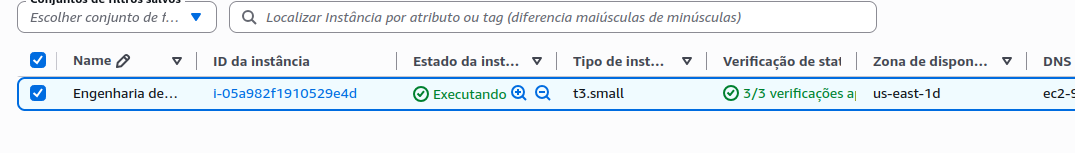

O problema a ser resolvido no kaggle é encontrado no link a seguir: [spaceship-titanic](https://www.kaggle.com/competitions/spaceship-titanic/overview)

O objetivo desse desafio é prever quais passageiros foram teletransportados a partir de dados resgatados.

In [52]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

## <a id="obtendo-dados"></a>Obtendo os dados

In [24]:
raw_data_train = pd.read_csv("train.csv")
raw_data_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [25]:
raw_data_test = pd.read_csv("test.csv")
raw_data_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


## <a id="explorando-dados"></a>Análise exploratória

In [26]:
raw_data_train.describe()


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [27]:
raw_data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [45]:
df = raw_data_train.drop(['PassengerId'], axis=1)

In [46]:
# separar nome pelos sobrenomes
def sobrenome(nome):
    if isinstance(nome, str): return nome.split()[1]
    else: return "s/n"


In [47]:
df.dropna(inplace=True)

In [48]:
df['Name'] = df['Name'].apply(sobrenome)

Explorando os dados percebi que os sobrenomes das pessoas tem certa relação com se foi teleportado ou não, vamos usar estatística e gráficos para provar a hipótese

In [32]:
tabela_contingencia = pd.crosstab(df['Name'], df['Transported'])

# Teste Qui-Quadrado
chi2, p_valor, dof, ex = stats.chi2_contingency(tabela_contingencia)

print(f"P-valor: {p_valor}")
if p_valor < 0.05:
    print("Rejeitamos a hipótese nula: O sobrenome TEM relação com ser transportado.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidências de relação pelo sobrenome.")

res = stats.contingency.association(tabela_contingencia, method="cramer")
print(f"V de Cramér: {res}")

P-valor: 1.6491034698206438e-05
Rejeitamos a hipótese nula: O sobrenome TEM relação com ser transportado.
V de Cramér: 0.6017017150373251


O sobrenome tem relação com ser transportado e é uma relação forte

Vamos separar a cabine:

In [49]:
df[["Deck", "Cabin_num", "Side"]] = df["Cabin"].str.split("/", expand=True)
df = df.drop('Cabin', axis=1)

In [34]:
def calcula_relação_correlacao(df):
    df_categorico = df.select_dtypes(include=['object', 'category', 'str']).columns
    df_numerico = df.select_dtypes(include=['number']).columns

    for coluna in df_categorico:
        print(f'[COLUNA]: {coluna}')
        tabela_contingencia = pd.crosstab(df[coluna], df['Transported'])

        # Teste Qui-Quadrado
        chi2, p_valor, dof, ex = stats.chi2_contingency(tabela_contingencia)
        
        print(f"P-valor: {p_valor}")
        if p_valor < 0.05:
            print(f"Rejeitamos a hipótese nula: {coluna} TEM relação com ser transportado.")
        else:
            print(f"Não rejeitamos a hipótese nula: Não há evidências de relação pelo {coluna}.")
        
        res = stats.contingency.association(tabela_contingencia, method="cramer")
        print(f"V de Cramér: {res}")
     
    for coluna in df_numerico:
        print(f'[COLUNA]: {coluna}')

        correlacao = df[coluna].corr(df['Transported'])

        print(f"A correlação entre {coluna} e Transported é: {correlacao}")
    


In [35]:
calcula_relação_correlacao(df)

[COLUNA]: HomePlanet
P-valor: 3.337896081387072e-55
Rejeitamos a hipótese nula: HomePlanet TEM relação com ser transportado.
V de Cramér: 0.1948759586087842
[COLUNA]: CryoSleep
P-valor: 3.170181308462424e-309
Rejeitamos a hipótese nula: CryoSleep TEM relação com ser transportado.
V de Cramér: 0.46280348215356626
[COLUNA]: Destination
P-valor: 2.0065472274358898e-23
Rejeitamos a hipótese nula: Destination TEM relação com ser transportado.
V de Cramér: 0.12578911282618588
[COLUNA]: VIP
P-valor: 0.0007929898796745834
Rejeitamos a hipótese nula: VIP TEM relação com ser transportado.
V de Cramér: 0.04226002786876537
[COLUNA]: Name
P-valor: 1.6491034698206438e-05
Rejeitamos a hipótese nula: Name TEM relação com ser transportado.
V de Cramér: 0.6017017150373251
[COLUNA]: Deck
P-valor: 3.2179345727714256e-63
Rejeitamos a hipótese nula: Deck TEM relação com ser transportado.
V de Cramér: 0.2168521081298717
[COLUNA]: Cabin_num
P-valor: 0.10596387862433884
Não rejeitamos a hipótese nula: Não há e

as colunas FoodCourt, ShoppingMall e Age não possuem boa correlação (linear)

a coluna VIP possui um baixo valor V de Cramér

Não há evidências de relação pelo Cabin_num

a coluna Side possui um baixo valor V de Cramér

vamos criar um pequeno modelo com Random Forest, a priori com todos os dados, posteriormente retirando colunas com baixa relação

In [43]:
#vamos retirar as seguintes colunas e testar novamente
# VIP, Cabin_num, FoodCourt, ShoppingMall, Age

# df = df.drop(columns=['VIP', 'Cabin_num', 'FoodCourt', 'ShoppingMall', 'Age'])

<Axes: xlabel='Transported'>

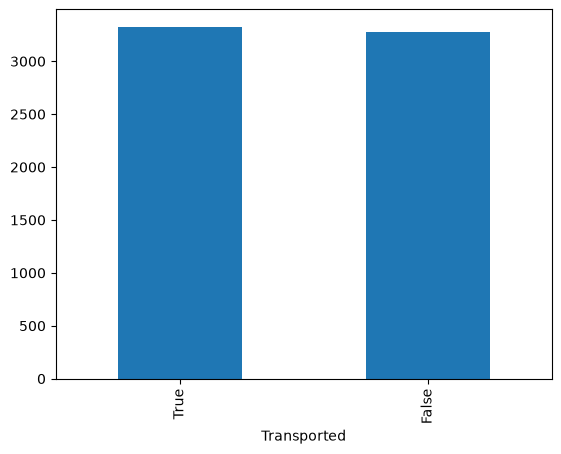

In [36]:
plot_df = df.Transported.value_counts()
plot_df.plot(kind="bar")

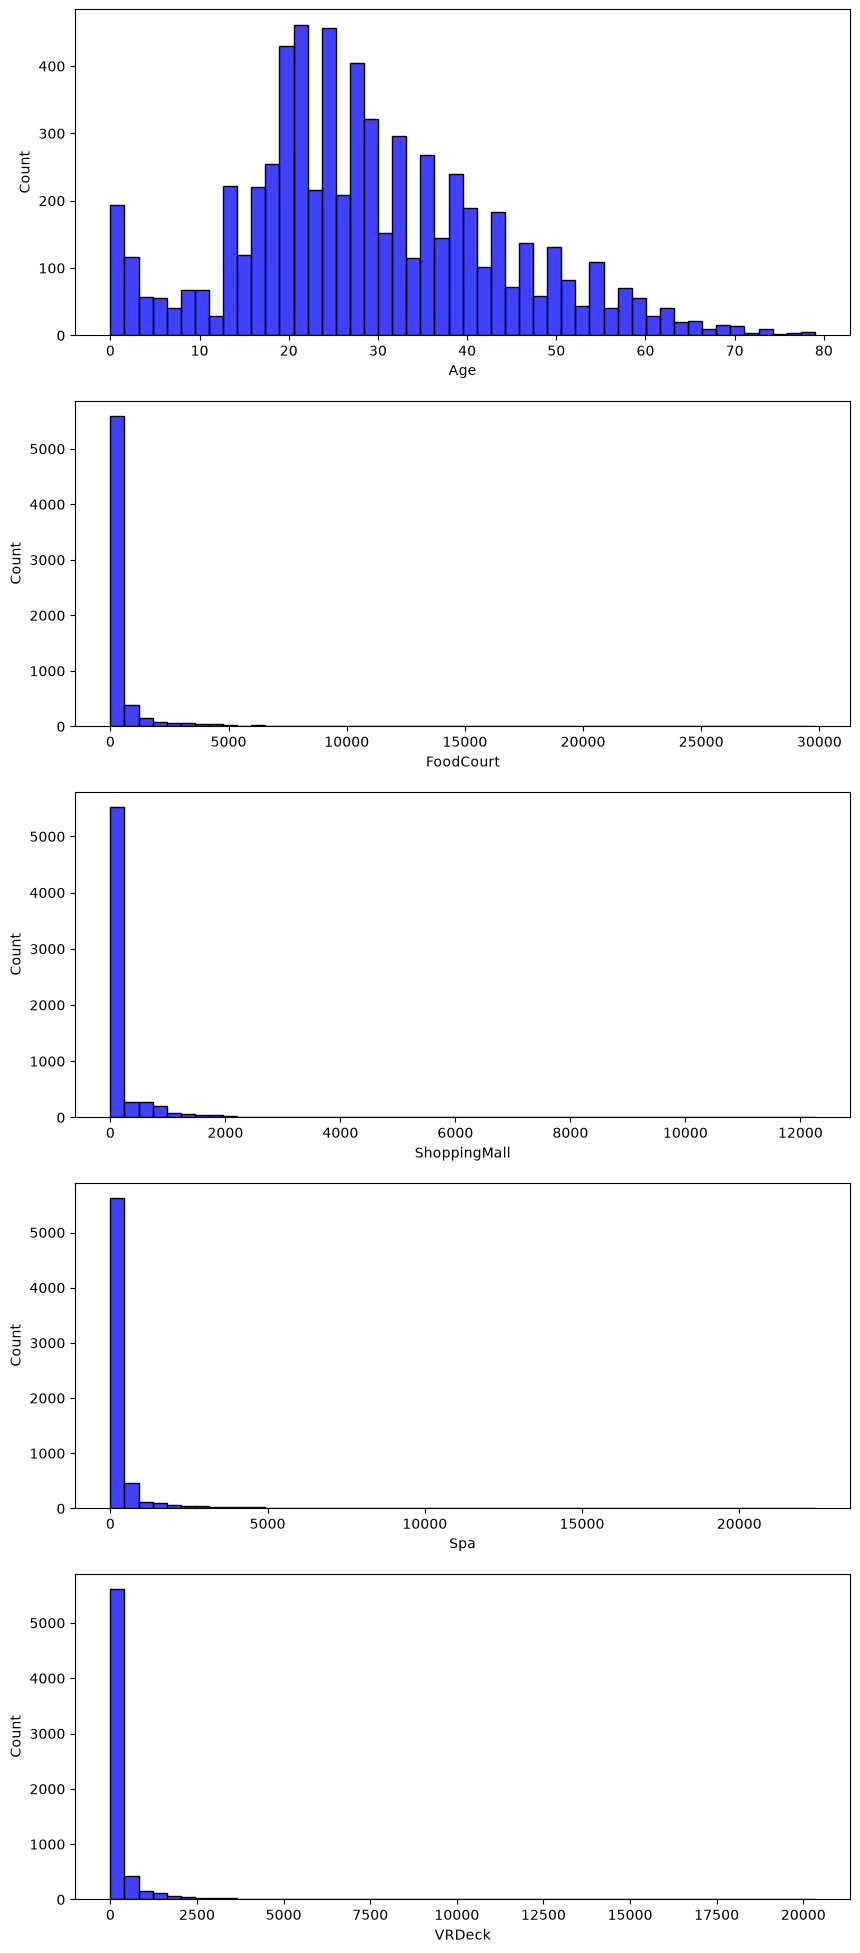

In [37]:
fig, ax = plt.subplots(5,1,  figsize=(10, 10))
plt.subplots_adjust(top = 2)

# sns.histplot(df['Age'], color='b', bins=50, ax=ax[0]);
# sns.histplot(df['FoodCourt'], color='b', bins=50, ax=ax[1]);
# sns.histplot(df['ShoppingMall'], color='b', bins=50, ax=ax[2]);
sns.histplot(df['Spa'], color='b', bins=50, ax=ax[3]);
sns.histplot(df['VRDeck'], color='b', bins=50, ax=ax[4]);

In [44]:

X = df.drop('Transported', axis=1) 
y = df['Transported']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para números: preenche vazios com a mediana
transformer_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline para categorias: preenche vazios com 'falta' e aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='falta')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# Unindo os dois no ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('num', transformer_numerico, colunas_numericas),
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('classificador', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.79      0.82      0.81       653
        True       0.82      0.78      0.80       669

    accuracy                           0.80      1322
   macro avg       0.80      0.80      0.80      1322
weighted avg       0.80      0.80      0.80      1322



In [42]:
df_test = raw_data_test.drop(['PassengerId'], axis=1)
df_test['Name'] = df_test['Name'].apply(sobrenome)
df_test[["Deck", "Cabin_num", "Side"]] = df_test["Cabin"].str.split("/", expand=True)
df_test = df_test.drop('Cabin', axis=1)
submission_id = raw_data_test['PassengerId']

predictions = modelo_pipeline.predict(df_test)

predictions_bool = predictions.astype(bool)

output = pd.DataFrame({
    'PassengerId': submission_id,
    'Transported': predictions_bool
})

output.to_csv('submission.csv', index=False)
print("Arquivo submission.csv gerado com sucesso!")

Arquivo submission.csv gerado com sucesso!


# Modelo XGBoost

In [53]:

X = df.drop('Transported', axis=1) 
y = df['Transported']              

# Dividindo em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
y_treino = y_treino.astype(int)

# Pega o nome das colunas numéricas (int e float)
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pega o nome das colunas categóricas (object/string)
colunas_categoricas = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# Pipeline para números: preenche vazios com a mediana
transformer_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline para categorias: preenche vazios com 'falta' e aplica One-Hot Encoding
transformer_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='falta')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore: se aparecer uma categoria nova no teste, ele não quebra
])

# Unindo os dois no ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('num', transformer_numerico, colunas_numericas),
        ('cat', transformer_categorico, colunas_categoricas)
    ])

# Aqui conectamos o tratamento de dados ao modelo Random Forest
modelo_pipeline = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('classificador', XGBClassifier(
        n_estimators=100,     # Número de árvores
        learning_rate=0.1,    # Velocidade de aprendizado (ajuda a não ter overfitting)
        max_depth=5,          # Profundidade máxima de cada árvore
        random_state=42
    ))
])

print("Treinando o modelo...")
modelo_pipeline.fit(X_treino, y_treino)

print("Fazendo previsões no conjunto de teste...")
previsoes = modelo_pipeline.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))

Treinando o modelo...
Fazendo previsões no conjunto de teste...

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.84      0.79      0.81       653
        True       0.81      0.85      0.83       669

    accuracy                           0.82      1322
   macro avg       0.82      0.82      0.82      1322
weighted avg       0.82      0.82      0.82      1322



In [54]:
df_test = raw_data_test.drop(['PassengerId'], axis=1)
df_test['Name'] = df_test['Name'].apply(sobrenome)
df_test[["Deck", "Cabin_num", "Side"]] = df_test["Cabin"].str.split("/", expand=True)
df_test = df_test.drop('Cabin', axis=1)
submission_id = raw_data_test['PassengerId']

predictions = modelo_pipeline.predict(df_test)

predictions_bool = predictions.astype(bool)

output = pd.DataFrame({
    'PassengerId': submission_id,
    'Transported': predictions_bool
})

output.to_csv('submission_xg.csv', index=False)
print("Arquivo submission_xg.csv gerado com sucesso!")

Arquivo submission_xg.csv gerado com sucesso!
